# 02：LDA 主题建模

## 2.1 导入库与基本设置

In [1]:
import pandas as pd
import re
import jieba
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="jieba")
import matplotlib.pyplot as plt
print("基础库导入完成")

F:\Users\lenovo\anaconda\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


基础库导入完成


## 2.2 文本预处理（去停用词、分词）

In [2]:
# 加载帖子数据
posts = pd.read_excel('Weibo_Posts_cleaned.xlsx')
print(f"原始帖子数：{len(posts)}")

# 加载自定义词典（确保人名完整）
jieba.load_userdict('custom_dict.txt')

# 加载停用词表
with open('stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = set(line.strip() for line in f if line.strip())

# 允许保留的英文词白名单
ALLOWED_ENGLISH = {'spotify', 'suno', 'rvc', 'ai','cover'}
    
# 定义文本清洗与分词函数
def clean_text(text):
    """去除URL、微博特有标记、话题标签、@用户，只保留中文字符、字母和数字"""
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'http\S+', '', text)          # 去URL
    text = re.sub(r'收起[dD]', '', text)         # 去“收起d”
    text = re.sub(r'网页链接', '', text)
    text = re.sub(r'专栏\s*', '', text)
    text = re.sub(r'#.*?#', '', text)            # 去话题标签
    text = re.sub(r'@\S+', '', text)             # 去@用户
    # 保留中文、字母、数字、空格，去掉其他标点
    text = re.sub(r'[^\u4e00-\u9fa5a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    if not text:
        return []
    words = jieba.lcut(text)
    filtered = []
    for w in words:
        if w in stopwords:
            continue
        if len(w) < 2 or w.isdigit():
            continue
        # 纯英文单词处理
        if re.fullmatch(r'[a-zA-Z]+', w):
            if w.lower() in ALLOWED_ENGLISH:
                filtered.append(w)
            continue
        filtered.append(w)
    return filtered

print("函数定义完成")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Lenovo\AppData\Local\Temp\jieba.cache


原始帖子数：899


Loading model cost 1.900 seconds.
Prefix dict has been built successfully.


函数定义完成


In [19]:
# 加载数据并分词
posts = pd.read_excel('Weibo_Posts_cleaned.xlsx')
posts['content_final'] = posts['content_clean'].apply(clean_text)
posts['tokens'] = posts['content_final'].apply(tokenize)
posts = posts[posts['tokens'].map(len) > 0].copy()
texts = posts['tokens'].tolist()
print(f"分词后有效帖子数：{len(posts)}")

分词后有效帖子数：893


## 2.3 构建词典与语料（用于LDA）

In [4]:
from gensim import corpora, models

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts]
print(f"词典大小：{len(dictionary)}")

词典大小：610


## 2.4 确定最佳主题数（连贯性曲线）

主题数 2: 连贯性 = 0.3047, 困惑度 = 357.68
主题数 3: 连贯性 = 0.3158, 困惑度 = 329.66
主题数 4: 连贯性 = 0.3172, 困惑度 = 341.87
主题数 5: 连贯性 = 0.3390, 困惑度 = 348.64
主题数 6: 连贯性 = 0.4203, 困惑度 = 329.54
主题数 7: 连贯性 = 0.3619, 困惑度 = 342.33
主题数 8: 连贯性 = 0.3833, 困惑度 = 341.53
主题数 9: 连贯性 = 0.3640, 困惑度 = 351.43
主题数 10: 连贯性 = 0.4036, 困惑度 = 343.84
主题数 11: 连贯性 = 0.3757, 困惑度 = 359.83
主题数 12: 连贯性 = 0.3804, 困惑度 = 353.37
主题数 13: 连贯性 = 0.4165, 困惑度 = 357.74
主题数 14: 连贯性 = 0.4259, 困惑度 = 361.92


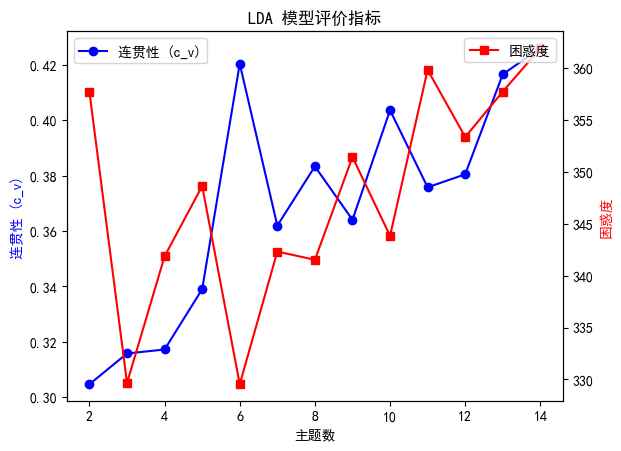

连贯性最高的主题数：14
困惑度最低的主题数：6


In [5]:
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

topic_range = range(2, 15)
coherence_scores = []
perplexity_scores = []

for k in topic_range:
    lda = models.LdaModel(corpus, num_topics=k, id2word=dictionary, passes=20, random_state=42)
    
    # 计算连贯性（c_v）
    cm = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())
    
    # 计算困惑度（perplexity，越低越好）
    # log_perplexity 返回以e为底的对数困惑度，实际困惑度 = exp(log_perplexity)
    log_perp = lda.log_perplexity(corpus)
    perplexity_scores.append(2.71828 ** (-log_perp))   # e^(-log_perp) 即真实困惑度
    
    print(f"主题数 {k}: 连贯性 = {coherence_scores[-1]:.4f}, 困惑度 = {perplexity_scores[-1]:.2f}")

# 绘制双轴图：左轴连贯性，右轴困惑度

plt.rcParams['font.sans-serif'] = ['SimHei']   # Windows
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(topic_range, coherence_scores, marker='o', color='b', label='连贯性 (c_v)')
ax2.plot(topic_range, perplexity_scores, marker='s', color='r', label='困惑度')

ax1.set_xlabel('主题数')
ax1.set_ylabel('连贯性 (c_v)', color='b')
ax2.set_ylabel('困惑度', color='r')
plt.title('LDA 模型评价指标')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

# 推荐：根据连贯性最大（或拐点）和困惑度最小综合判断
best_k_coherence = topic_range[coherence_scores.index(max(coherence_scores))]
best_k_perplexity = topic_range[perplexity_scores.index(min(perplexity_scores))]
print(f"连贯性最高的主题数：{best_k_coherence}")
print(f"困惑度最低的主题数：{best_k_perplexity}")

## 2.5 训练最终LDA模型并输出主题关键词

In [11]:
topic_keywords = []
for i in range(6):   # 你的主题数是6
    keywords = lda.show_topic(i, topn=15)
    keyword_str = ', '.join([kw for kw, _ in keywords])
    topic_keywords.append({'topic_id': i, 'keywords': keyword_str})
    # 打印当前主题的关键词
    print(f"主题 {i}: {keyword_str}")

# 保存为 Excel
df_topics = pd.DataFrame(topic_keywords)
df_topics.to_excel('LDA_topic_keywords_k6.xlsx', index=False)
print("已保存主题关键词到 LDA_topic_keywords_k6.xlsx")

主题 0: 陈浚铭, 宝宝, 好听, 真的, 唱歌, 特别, 终于, 喜欢, 粉丝, 超话, 哔哩, 幸福, 可爱, 声音, 听到
主题 1: ai, cover, 翻唱, 窦靖童, 真的, 王菲, 粉丝, 音色, 感觉, 语音, 手机, 好像, 不想, 想要, 时间
主题 2: AI, 公司, 产品, 模型, 技术, 生成, 客户, 成本, 发展, 价值, 持续, 行业, 人类, 市场, 传统
主题 3: 橹穆, AI, 超话, 翻唱, ai, cover, 原唱, 声音, Cover, 时间, 产出, COVER, 真的, 喜欢, 联产
主题 4: 歌手, 翻唱, 音乐, 舞台, AI, 改编, 经典, 老歌, 首歌, 演唱, 演绎, 情绪, 灵魂, 一首, 旋律
主题 5: AI, 翻唱, 音乐, 歌曲, 抖音, 创作, 制作, 作品, 功能, Spotify, 用户, 支持, 版本, 内容, 艺人
已保存主题关键词到 LDA_topic_keywords_k6.xlsx


## 2.6 保存结果

In [18]:
# 定义函数：获取每条帖子的主导主题
def get_dominant_topic(bow):
    topics = lda.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]

# 为帖子分配主题
posts['topic'] = [get_dominant_topic(bow) for bow in corpus]

# 主题名称映射（根据之前的命名）
topic_names = {
    0: '偶像粉丝安利',
    1: '歌手音色讨论',
    2: '产业与技术商业',
    3: '粉丝联合创作',
    4: '经典歌手翻唱',
    5: '翻唱传播与平台合规'
}
posts['topic_name'] = posts['topic'].map(topic_names)

# 统计每个主题的帖子数
topic_counts = posts['topic'].value_counts().sort_index()
total = len(posts)

print("各主题帖子数及占比：")
for i in range(6):
    cnt = topic_counts.get(i, 0)
    pct = cnt / total * 100
    print(f"{topic_names[i]}: {cnt} 条 ({pct:.1f}%)")

import pandas as pd

# 假设 topic_counts 和 topic_names 已经存在
# 如果还没有运行分配主题的代码，请先运行你提供的那段代码

# 构建统计表格
summary_list = []
for i in range(6):
    cnt = topic_counts.get(i, 0)
    pct = cnt / total * 100
    summary_list.append({
        '主题ID': i,
        '主题名称': topic_names[i],
        '帖子数': cnt,
        '占比(%)': round(pct, 1)
    })

df_summary = pd.DataFrame(summary_list)

# 保存为 CSV 文件
df_summary.to_csv('topic_statistics.csv', index=False, encoding='utf-8-sig')
print("主题统计表已保存为 topic_statistics.csv")

# 保存带主题标签的帖子表
posts.to_excel('Weibo_Posts_with_topic.xlsx', index=False)
print("已保存带主题标签的帖子表")

各主题帖子数及占比：
偶像粉丝安利: 241 条 (27.0%)
歌手音色讨论: 207 条 (23.2%)
产业与技术商业: 56 条 (6.3%)
粉丝联合创作: 176 条 (19.7%)
经典歌手翻唱: 120 条 (13.4%)
翻唱传播与平台合规: 93 条 (10.4%)
主题统计表已保存为 topic_statistics.csv
已保存带主题标签的帖子表


## 2.7 LDA 可视化

In [13]:
try:
    import pyLDAvis.gensim_models as gensimvis
    import pyLDAvis
    vis_data = gensimvis.prepare(lda, corpus, dictionary)
    pyLDAvis.display(vis_data)
    pyLDAvis.save_html(vis_data, 'lda_visualization.html')
    print("已保存 LDA 可视化 html 文件")
except ImportError:
    print("未安装 pyLDAvis，跳过可视化。如需安装请运行：pip install pyLDAvis")

已保存 LDA 可视化 html 文件
